# Notebook 02 — Feature EDA

Exploratory analysis of the feature matrix produced by `mlb/features.py`.

**Goals:**
1. Confirm no-leakage structure in the feature matrix
2. Understand feature distributions and null rates
3. Quantify signal: correlation of each feature with targets
4. Check Poisson fit + overdispersion → confirm NegBinom need
5. Assess market line quality (baseline to beat)
6. Weather and park factor impact

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from mlb.features import build_features, FEATURE_COLS, TARGET_COLS
from mlb.db import get_conn

DB_PATH = '../data/mlb.db'
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('imports OK')

imports OK


## 1. Build Feature Matrix

In [2]:
# Use full 2022 season — most complete data
df = build_features(start_date='2022-04-07', end_date='2022-10-05', db_path=DB_PATH)
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'\nFeature columns: {len(FEATURE_COLS)}')
print(f'Target columns: {TARGET_COLS}')

Shape: (2430, 60)
Date range: 2022-04-07 to 2022-10-05

Feature columns: 49
Target columns: ['home_runs', 'away_runs', 'total_runs']


In [3]:
# Null rates — flag anything > 5%
null_pct = df[FEATURE_COLS].isna().mean().mul(100).round(1).sort_values(ascending=False)
high_null = null_pct[null_pct > 5]
print(f'Features with >5% null ({len(high_null)} of {len(FEATURE_COLS)}):')
for col, pct in high_null.items():
    bar = '#' * int(pct / 2)
    print(f'  {col:<35} {pct:5.1f}%  {bar}')

print(f'\nFeatures with 0% null: {(null_pct == 0).sum()}')
print(f'Features with <5% null: {(null_pct < 5).sum()}')

Features with >5% null (19 of 49):
  precip_prob                         100.0%  ##################################################
  sp_fip_combined                      11.7%  #####
  sp_era_l3_combined                   11.7%  #####
  sp_k9_combined                       11.7%  #####
  away_sp_era_l3                        7.9%  ###
  away_sp_days_rest                     7.9%  ###
  away_sp_fip_season                    7.9%  ###
  away_sp_bb9_season                    7.9%  ###
  away_sp_era_season                    7.9%  ###
  away_sp_k9_season                     7.9%  ###
  home_sp_era_season                    7.2%  ###
  home_sp_fip_season                    7.2%  ###
  home_sp_bb9_season                    7.2%  ###
  home_sp_days_rest                     7.2%  ###
  home_sp_era_l3                        7.2%  ###
  home_sp_k9_season                     7.2%  ###
  wind_speed_mph                        6.7%  ###
  humidity                              6.7%  ###
  temp_f    

## 2. Target Variable EDA + Overdispersion

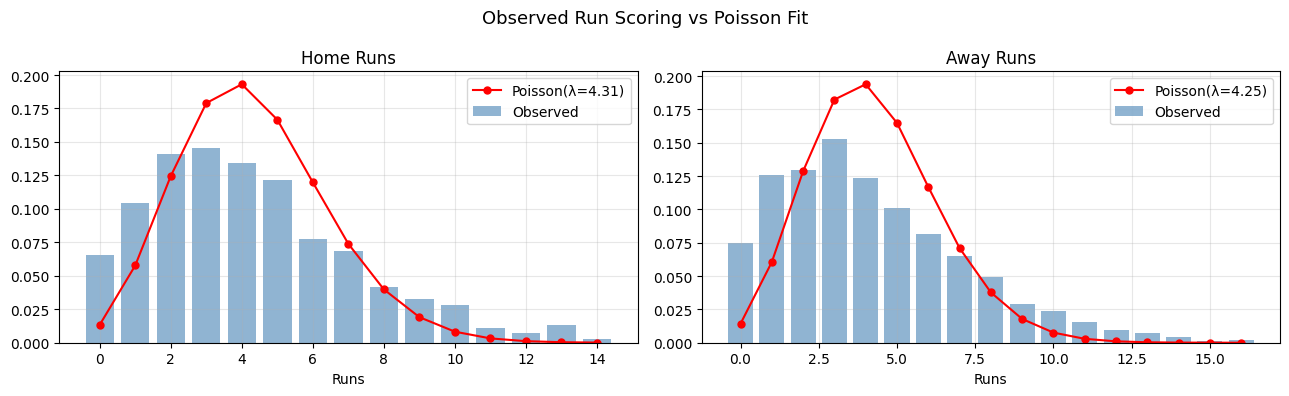

Overdispersion check:
  home_runs: mean=4.314, var=9.193, dispersion=2.131  *** NEGBINOM NEEDED ***
  away_runs: mean=4.252, var=10.149, dispersion=2.387  *** NEGBINOM NEEDED ***


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], 'home_runs', 'Home Runs'),
    (axes[1], 'away_runs', 'Away Runs'),
]:
    vals = df[col].dropna().astype(int)
    lam = vals.mean()
    k_max = int(vals.quantile(0.995))
    ks = np.arange(0, k_max + 1)

    obs = vals.value_counts(normalize=True).reindex(ks, fill_value=0)
    ax.bar(ks, obs.values, alpha=0.6, label='Observed', color='steelblue')
    ax.plot(ks, poisson.pmf(ks, lam), 'ro-', ms=5, label=f'Poisson(λ={lam:.2f})')
    ax.set_title(f'{label}')
    ax.set_xlabel('Runs')
    ax.legend()

plt.suptitle('Observed Run Scoring vs Poisson Fit', fontsize=13)
plt.tight_layout()
plt.show()

print('Overdispersion check:')
for col in ['home_runs', 'away_runs']:
    vals = df[col].dropna()
    d = vals.var() / vals.mean()
    flag = '*** NEGBINOM NEEDED ***' if d > 1.2 else 'OK (Poisson adequate)'
    print(f'  {col}: mean={vals.mean():.3f}, var={vals.var():.3f}, dispersion={d:.3f}  {flag}')

## 3. Starting Pitcher Features

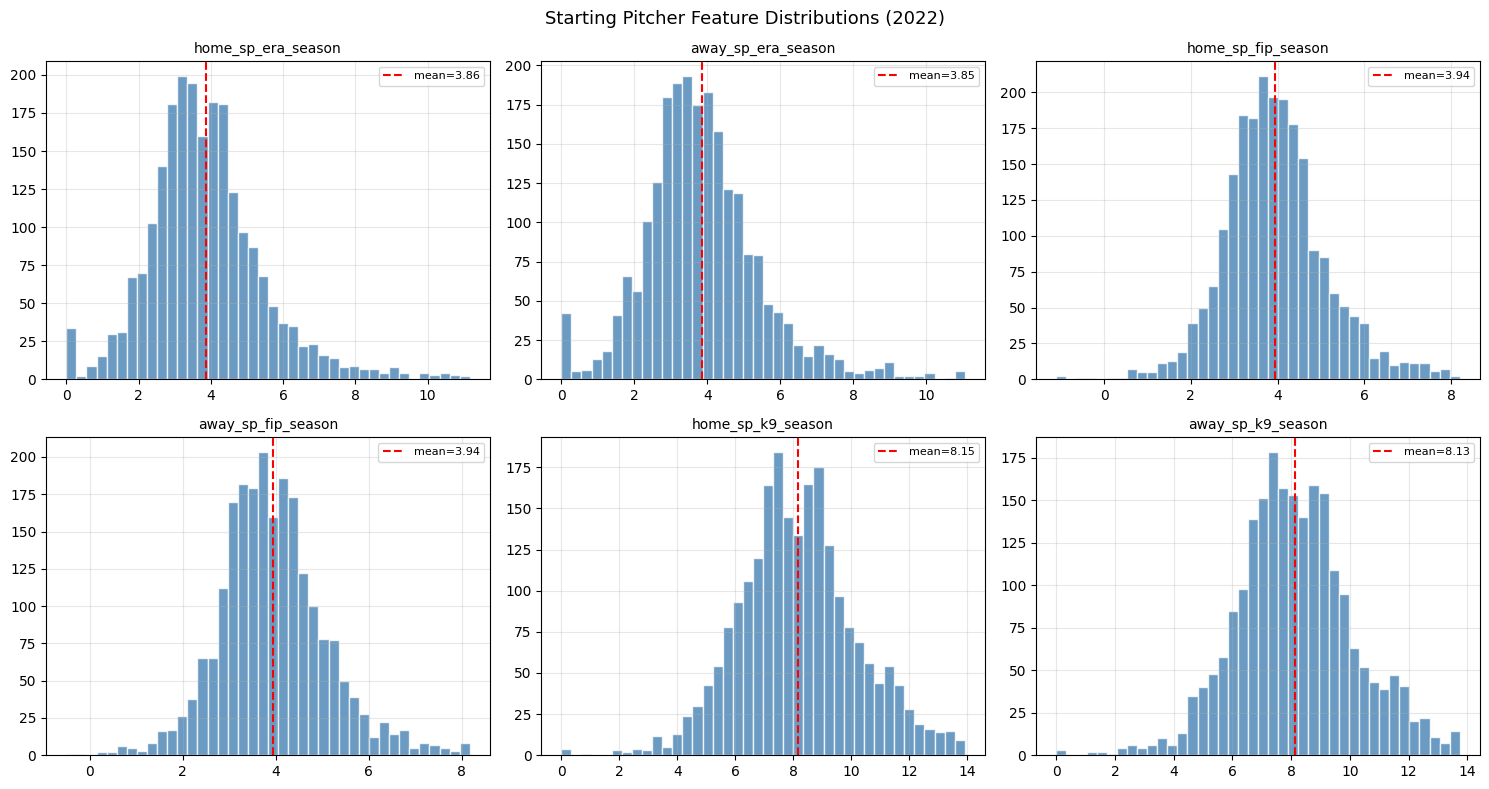

In [5]:
sp_feats = [
    'home_sp_era_season', 'away_sp_era_season',
    'home_sp_fip_season', 'away_sp_fip_season',
    'home_sp_k9_season',  'away_sp_k9_season',
]
present = [c for c in sp_feats if c in df.columns]

ncols = 3
nrows = (len(present) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(present):
    vals = df[col].dropna()
    vals = vals[vals < vals.quantile(0.99)]
    axes[i].hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(vals.mean(), color='red', linestyle='--', label=f'mean={vals.mean():.2f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Starting Pitcher Feature Distributions (2022)', fontsize=13)
plt.tight_layout()
plt.show()

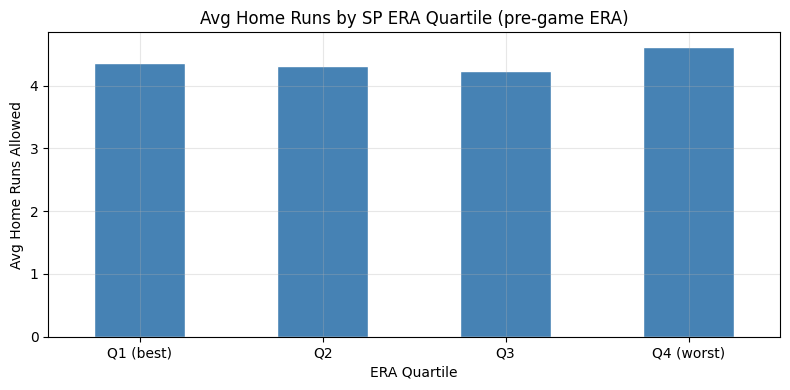

Avg runs by ERA quartile:
era_q
Q1 (best)     4.357
Q2            4.314
Q3            4.224
Q4 (worst)    4.617

home_sp_era_season vs home_runs corr: 0.028


In [6]:
# ERA vs runs allowed — sanity check that lower ERA = fewer runs (no leakage)
sub = df.dropna(subset=['home_sp_era_season', 'home_runs'])
sub = sub[sub['home_sp_era_season'] < 10]  # clip extremes

# Bin ERA into quartiles
sub['era_q'] = pd.qcut(sub['home_sp_era_season'], q=4, labels=['Q1 (best)', 'Q2', 'Q3', 'Q4 (worst)'])
era_runs = sub.groupby('era_q', observed=True)['home_runs'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
era_runs.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Avg Home Runs by SP ERA Quartile (pre-game ERA)')
ax.set_ylabel('Avg Home Runs Allowed')
ax.set_xlabel('ERA Quartile')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Avg runs by ERA quartile:')
print(era_runs.round(3).to_string())
print(f'\nhome_sp_era_season vs home_runs corr: {sub["home_sp_era_season"].corr(sub["home_runs"]):.3f}')

## 4. Team Offense Features

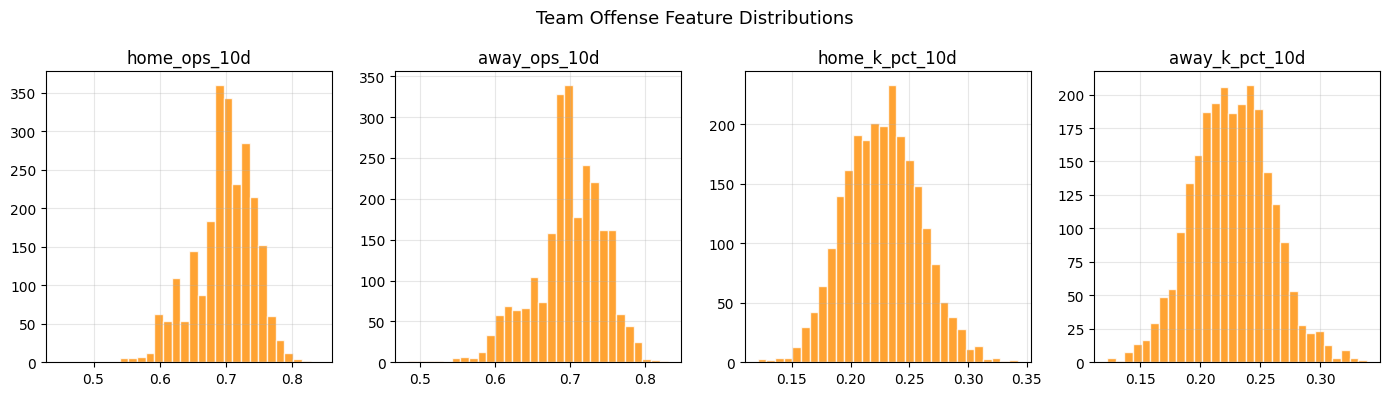

home_ops_10d vs home_runs corr: r=0.085  (expected positive)


In [7]:
offense_feats = ['home_ops_10d', 'away_ops_10d', 'home_k_pct_10d', 'away_k_pct_10d']
present_off = [c for c in offense_feats if c in df.columns]

fig, axes = plt.subplots(1, len(present_off), figsize=(14, 4))
if len(present_off) == 1:
    axes = [axes]
for ax, col in zip(axes, present_off):
    df[col].dropna().hist(bins=30, ax=ax, color='darkorange', edgecolor='white', alpha=0.8)
    ax.set_title(col)
plt.suptitle('Team Offense Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# OPS vs runs scored — sanity check
if 'home_ops_10d' in df.columns:
    sub2 = df.dropna(subset=['home_ops_10d', 'home_runs'])
    r = sub2['home_ops_10d'].corr(sub2['home_runs'])
    print(f'home_ops_10d vs home_runs corr: r={r:.3f}  (expected positive)')

## 5. Elo Features

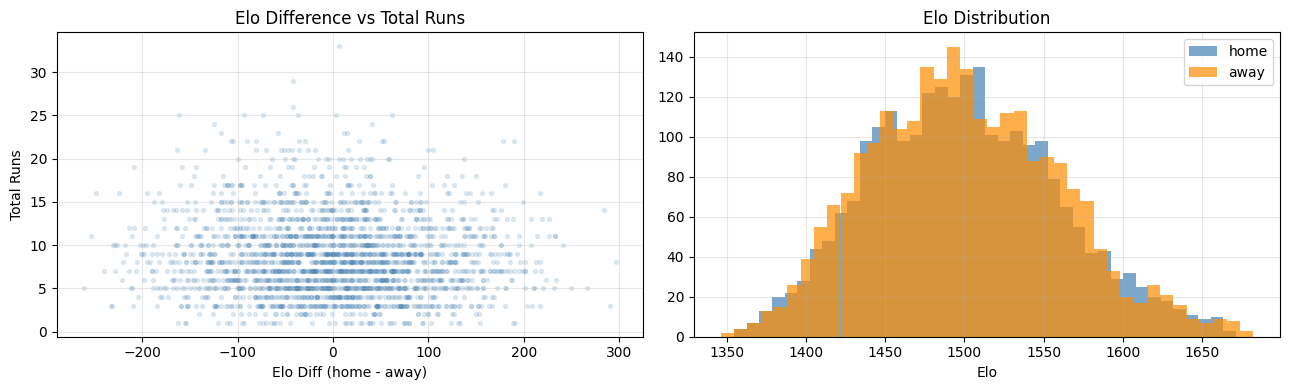

elo_home vs total_runs: r=-0.050
elo_diff  vs total_runs: r=-0.057
elo_diff  vs home_runs:  r=0.094  (expected positive — better home team = more home runs)


In [8]:
df['elo_diff'] = df['elo_home'] - df['elo_away']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elo diff vs total runs
sub_elo = df.dropna(subset=['elo_diff', 'total_runs'])
axes[0].scatter(sub_elo['elo_diff'], sub_elo['total_runs'],
                alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('Elo Diff (home - away)')
axes[0].set_ylabel('Total Runs')
axes[0].set_title('Elo Difference vs Total Runs')

# Elo distribution
df['elo_home'].dropna().hist(bins=40, ax=axes[1], color='steelblue', alpha=0.7, label='home')
df['elo_away'].dropna().hist(bins=40, ax=axes[1], color='darkorange', alpha=0.7, label='away')
axes[1].set_title('Elo Distribution')
axes[1].set_xlabel('Elo')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'elo_home vs total_runs: r={df["elo_home"].corr(df["total_runs"]):.3f}')
print(f'elo_diff  vs total_runs: r={df["elo_diff"].corr(df["total_runs"]):.3f}')
print(f'elo_diff  vs home_runs:  r={df["elo_diff"].corr(df["home_runs"]):.3f}  (expected positive — better home team = more home runs)')

## 6. Market Features (SBR Closing Lines)

Games with closing line: 2328 / 2430 (95.8%)
       total_line_open  total_line_close  line_movement
count         2328.000          2328.000       2328.000
mean             8.219             8.204         -0.014
std              0.940             0.986          0.401
min              6.000             6.000         -1.900
25%              7.500             7.500         -0.300
50%              8.100             8.100          0.000
75%              8.600             8.700          0.200
max             12.600            12.500          4.400


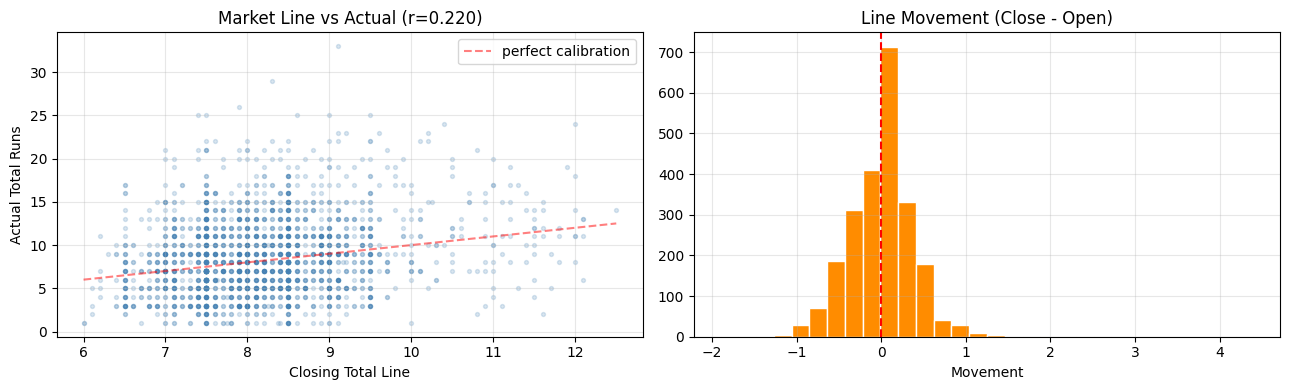


Close line vs actual total: r=0.220
  This is the signal quality ceiling — our model must approach this.

Over hit rate vs closing line: 47.5%  (50% = fair)
  Slight UNDER bias — overs may have structural edge


In [9]:
line_feats = ['total_line_open', 'total_line_close', 'line_movement']
present_lines = [c for c in line_feats if c in df.columns]

non_null = df[present_lines].dropna()
print(f'Games with closing line: {len(non_null)} / {len(df)} ({len(non_null)/len(df)*100:.1f}%)')

if len(non_null) > 0:
    print(non_null[present_lines].describe().round(3).to_string())

    # Close line vs actual total — the key baseline
    sub_l = df.dropna(subset=['total_line_close', 'total_runs'])
    r_close = sub_l['total_line_close'].corr(sub_l['total_runs'])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(sub_l['total_line_close'], sub_l['total_runs'],
                    alpha=0.2, s=8, color='steelblue')
    mn = sub_l['total_line_close'].min()
    mx = sub_l['total_line_close'].max()
    axes[0].plot([mn, mx], [mn, mx], 'r--', alpha=0.5, label='perfect calibration')
    axes[0].set_xlabel('Closing Total Line')
    axes[0].set_ylabel('Actual Total Runs')
    axes[0].set_title(f'Market Line vs Actual (r={r_close:.3f})')
    axes[0].legend()

    if 'line_movement' in non_null.columns:
        non_null['line_movement'].hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
        axes[1].axvline(0, color='red', linestyle='--')
        axes[1].set_title('Line Movement (Close - Open)')
        axes[1].set_xlabel('Movement')

    plt.tight_layout()
    plt.show()

    print(f'\nClose line vs actual total: r={r_close:.3f}')
    print('  This is the signal quality ceiling — our model must approach this.')

    # Over/under bias check
    sub_l2 = df.dropna(subset=['total_line_close', 'total_runs']).copy()
    sub_l2['result'] = (sub_l2['total_runs'] > sub_l2['total_line_close']).astype(int)
    over_rate = sub_l2['result'].mean()
    print(f'\nOver hit rate vs closing line: {over_rate*100:.1f}%  (50% = fair)')
    if over_rate > 0.52:
        print('  Slight OVER bias — unders may have structural edge')
    elif over_rate < 0.48:
        print('  Slight UNDER bias — overs may have structural edge')
    else:
        print('  No significant over/under bias detected')

## 7. Weather Impact

Outdoor games with weather: 2268


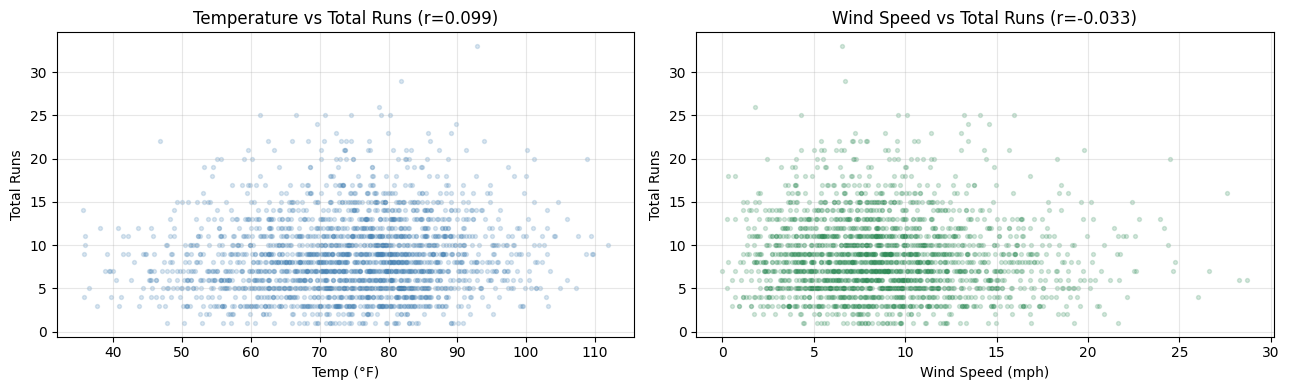

Cold (<50°F): 7.57 avg runs  (79 games)
Warm (>75°F): 8.92 avg runs  (1163 games)
wind_dir_out: on=8.92 vs off=8.47, diff=+0.45
wind_dir_in: on=8.63 vs off=8.58, diff=+0.05


In [10]:
outdoor = df[(df['is_dome'] == 0)].dropna(subset=['temp_f', 'total_runs'])
print(f'Outdoor games with weather: {len(outdoor)}')

if len(outdoor) > 30:
    r_temp = outdoor['temp_f'].corr(outdoor['total_runs'])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(outdoor['temp_f'], outdoor['total_runs'],
                    alpha=0.2, s=8, color='steelblue')
    axes[0].set_xlabel('Temp (°F)')
    axes[0].set_ylabel('Total Runs')
    axes[0].set_title(f'Temperature vs Total Runs (r={r_temp:.3f})')

    # Wind speed vs runs
    sub_wind = outdoor.dropna(subset=['wind_speed_mph'])
    if len(sub_wind) > 20:
        r_wind = sub_wind['wind_speed_mph'].corr(sub_wind['total_runs'])
        axes[1].scatter(sub_wind['wind_speed_mph'], sub_wind['total_runs'],
                        alpha=0.2, s=8, color='seagreen')
        axes[1].set_xlabel('Wind Speed (mph)')
        axes[1].set_ylabel('Total Runs')
        axes[1].set_title(f'Wind Speed vs Total Runs (r={r_wind:.3f})')

    plt.tight_layout()
    plt.show()

    # Cold vs warm
    cold = outdoor[outdoor['temp_f'] < 50]['total_runs']
    warm = outdoor[outdoor['temp_f'] > 75]['total_runs']
    if len(cold) > 5 and len(warm) > 5:
        print(f'Cold (<50°F): {cold.mean():.2f} avg runs  ({len(cold)} games)')
        print(f'Warm (>75°F): {warm.mean():.2f} avg runs  ({len(warm)} games)')

    # Wind direction effect
    wind_cols = [c for c in ['wind_dir_out', 'wind_dir_in'] if c in df.columns]
    for wc in wind_cols:
        grp = outdoor.groupby(wc)['total_runs'].agg(['mean', 'count'])
        if len(grp) == 2:
            diff = grp.loc[1, 'mean'] - grp.loc[0, 'mean']
            print(f'{wc}: on={grp.loc[1,"mean"]:.2f} vs off={grp.loc[0,"mean"]:.2f}, diff={diff:+.2f}')
else:
    print('Insufficient outdoor weather data')

## 8. Feature–Target Correlations

In [11]:
corr_total = df[FEATURE_COLS].corrwith(df['total_runs']).dropna().abs().sort_values(ascending=False)
corr_home  = df[FEATURE_COLS].corrwith(df['home_runs']).dropna().abs().sort_values(ascending=False)
corr_away  = df[FEATURE_COLS].corrwith(df['away_runs']).dropna().abs().sort_values(ascending=False)

print('Top 20 features by |corr| with total_runs:')
print(corr_total.head(20).round(3).to_string())

Top 20 features by |corr| with total_runs:
total_line_close      0.220
total_line_open       0.195
park_run_factor       0.132
park_elevation_ft     0.127
park_hr_factor        0.119
temp_f                0.099
line_movement         0.084
humidity              0.083
home_sp_fip_season    0.074
sp_k9_combined        0.061
sp_fip_combined       0.053
elo_home              0.050
wind_dir_out          0.047
home_sp_era_season    0.046
home_sp_era_l3        0.042
home_sp_k9_season     0.042
elo_away              0.035
wind_speed_mph        0.033
away_k_pct_10d        0.032
away_sp_k9_season     0.030


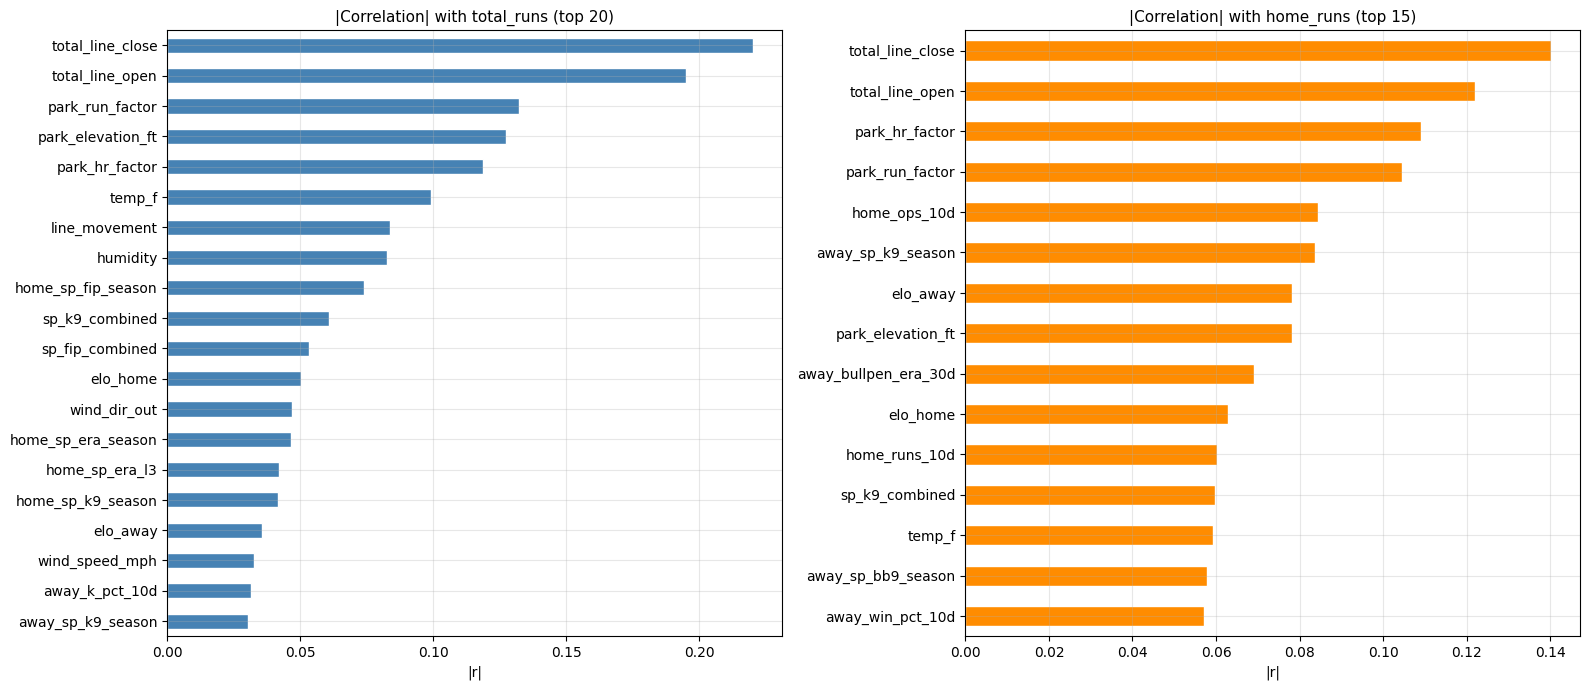

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

corr_total.head(20).plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('|Correlation| with total_runs (top 20)', fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('|r|')

corr_home.head(15).plot.barh(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('|Correlation| with home_runs (top 15)', fontsize=11)
axes[1].invert_yaxis()
axes[1].set_xlabel('|r|')

plt.tight_layout()
plt.show()

In [13]:
# Signed correlations — which direction does each feature push?
signed = df[FEATURE_COLS].corrwith(df['total_runs']).dropna().sort_values()
print('Most negative correlations with total_runs (run-suppressing features):')
print(signed.head(10).round(3).to_string())
print('\nMost positive correlations with total_runs (run-promoting features):')
print(signed.tail(10).round(3).to_string())

Most negative correlations with total_runs (run-suppressing features):
humidity               -0.083
sp_k9_combined         -0.061
elo_home               -0.050
home_sp_k9_season      -0.042
wind_speed_mph         -0.033
away_k_pct_10d         -0.032
away_sp_k9_season      -0.030
home_win_pct_10d       -0.024
is_dome                -0.022
wind_dir_cross_right   -0.021

Most positive correlations with total_runs (run-promoting features):
wind_dir_out          0.047
sp_fip_combined       0.053
home_sp_fip_season    0.074
line_movement         0.084
temp_f                0.099
park_hr_factor        0.119
park_elevation_ft     0.127
park_run_factor       0.132
total_line_open       0.195
total_line_close      0.220


## 9. EDA Summary

In [14]:
print('FEATURE EDA SUMMARY')
print('=' * 65)

# Coverage
avail = df[FEATURE_COLS].notna().mean().mul(100)
print(f'Feature coverage:')
print(f'  >90% available: {(avail > 90).sum()} / {len(FEATURE_COLS)} features')
print(f'  >70% available: {(avail > 70).sum()} / {len(FEATURE_COLS)} features')
print(f'  <50% available: {(avail < 50).sum()} / {len(FEATURE_COLS)} features')

# Overdispersion verdict
print(f'\nOverdispersion:')
for col in ['home_runs', 'away_runs']:
    vals = df[col].dropna()
    d = vals.var() / vals.mean()
    verdict = 'UPGRADE TO NEGBINOM' if d > 1.2 else 'Poisson OK'
    print(f'  {col}: dispersion={d:.3f}  → {verdict}')

# Best single-feature signals
print(f'\nTop 5 predictive features (|r| with total_runs):')
for feat, r in corr_total.head(5).items():
    print(f'  {feat:<40} r={r:.3f}')

# Market baseline
if 'total_line_close' in df.columns:
    sub_m = df.dropna(subset=['total_line_close', 'total_runs'])
    r_mkt = sub_m['total_line_close'].corr(sub_m['total_runs'])
    print(f'\nMarket baseline (close line vs actual): r={r_mkt:.3f}')
    print(f'  Model must approach this to generate edge')

print(f'\nReady for Step 16: mlb/model.py')
print('=' * 65)

FEATURE EDA SUMMARY
Feature coverage:
  >90% available: 45 / 49 features
  >70% available: 48 / 49 features
  <50% available: 1 / 49 features

Overdispersion:
  home_runs: dispersion=2.131  → UPGRADE TO NEGBINOM
  away_runs: dispersion=2.387  → UPGRADE TO NEGBINOM

Top 5 predictive features (|r| with total_runs):
  total_line_close                         r=0.220
  total_line_open                          r=0.195
  park_run_factor                          r=0.132
  park_elevation_ft                        r=0.127
  park_hr_factor                           r=0.119

Market baseline (close line vs actual): r=0.220
  Model must approach this to generate edge

Ready for Step 16: mlb/model.py
